In [1]:
from __Global__ import *

C:\ProgramData\miniforge3\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
class plot_CV_trend_among_models2:
    def __init__(self):
        self.map_width = 13 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor
        pass
    def run(self):
        self.plot_CV_trend_among_models2()


    def plot_CV_trend_among_models2(self):  ##here not calculating mean in program

        color_list = ['black', 'black', 'black', 'black', '#E7483D', '#a1a9d0',
                      '#f0988c', '#b883d3', '#ffff33', '#c4a5de',
                      '#984ea3', 'yellow',
                      '#9e9e9e', '#cfeaf1', '#f6cae5',
                      '#98cccb', '#5867AF', '#e66d50', ]


        mark_size_list = [200] * 1 + [50] * 3 + [200] * 1 + [50] * 13

        dff = result_root + rf'\Upload_Data\Figure3\Trends_CV\\Trends_CV_area_weighted.df'
        df = T.load_df(dff)
        df = self.df_clean(df)
        # T.print_head_n(df)
        # print(df.columns.tolist())
        ## print column names
        # print(df.columns)
        # exit()
        marker_list = ['^', 's', 'P', 'X', 'D'] * 4

        variables_list = ['composite_LAI_mean', 'LAI4g', 'GLOBMAP_LAI',
                          'SNU_LAI',
                          'TRENDY_ensemble_median',
                          'CABLE-POP_S2_lai', 'CLASSIC_S2_lai',
                          'CLM5', 'DLEM_S2_lai', 'IBIS_S2_lai', 'ISAM_S2_lai',
                          'ISBA-CTRIP_S2_lai', 'JSBACH_S2_lai',
                          'JULES_S2_lai', 'LPJ-GUESS_S2_lai', 'LPX-Bern_S2_lai',
                          'ORCHIDEE_S2_lai',

                          'YIBs_S2_Monthly_lai']
        vals_trend_list = []
        vals_CV_list = []
        err_trend_list = []
        err_CV_list = []

        for variable in variables_list:
            vals_trend = df[f'{variable}_relative_change_trend'].values
            vals_CV = df[f'{variable}_detrend_CV_trend'].values
            valid = (
                    np.isfinite(vals_CV) &
                    (vals_CV > -999) & (vals_CV < 999)
            )
            weight = np.array(df['area_weight'].tolist(), dtype=float)
            weighted_mean_values_CV = (
                    np.sum(vals_CV[valid] * weight[valid])
                    / np.sum(weight[valid])
            )
            valid_trend = (
                    np.isfinite(vals_trend) &
                    (vals_trend > -999) & (vals_trend < 999)
            )

            weighted_mean_values_trend = (
                    np.sum(vals_trend[valid_trend] * weight[valid_trend])
                    / np.sum(weight[valid_trend])
            )

            vals_trend_list.append(weighted_mean_values_trend)
            vals_CV_list.append(weighted_mean_values_CV)
        # print(vals_trend_list)
        # print(vals_CV_list);exit()
        ### ranking vals_trend_list
        vals_trend_list = np.array(vals_trend_list)
        vals_trend_list_sort = np.sort(vals_trend_list)

        # print(vals_trend_list_sort)

        vals_CV_list = np.array(vals_CV_list)
        vals_CV_list_sort = np.sort(vals_CV_list)

        # print(vals_CV_list_sort);
        # exit()



        n = len(variables_list)
        mark_size_list = mark_size_list[:n]
        color_list = color_list[:n]
        marker_list = marker_list[:n]

        # plt.scatter(vals_CV_list,vals_trend_list,marker=marker_list,color=color_list[0],s=100)
        # plt.show()
        ##plot error bar
        # plt.figure(figsize=(self.map_width, self.map_height))

        plt.figure(figsize=(13 * centimeter_factor, 10 * centimeter_factor))

        # self.map_width = 13 * centimeter_factor
        # self.map_height = 8.2 * centimeter_factor

        err_trend_list = np.array(err_trend_list)
        err_CV_list = np.array(err_CV_list)
        for i, (x, y, marker, color, var, mark_size) in enumerate(
                zip(vals_trend_list, vals_CV_list, marker_list, color_list, variables_list, mark_size_list)):
            plt.scatter(y, x, marker=marker, color=color_list[i], label=var, s=mark_size, edgecolors='black', )
            # plt.errorbar(y, x, xerr=err_trend_list[i], yerr=err_CV_list[i], fmt='none', color='grey', capsize=2, capthick=0.3,alpha=1)

            ##markerborderwidth=1

            plt.ylabel('Trends in LAI (%/yr)', fontsize=12)
            plt.xlabel('Trends in CVLAI (%/yr)', fontsize=12)
            plt.ylim(-0.3, .9)
            plt.xlim(-0.2, 0.5)
            plt.xticks(fontsize=12)
            ## xticks gap 0.05
            plt.yticks(np.arange(-0.2, .9, 0.2), fontsize=12)
            plt.yticks(fontsize=12)
            # plt.legend()
        ## save imagine
        # plt.axhline(y=0.0, color='k', linestyle='--', linewidth=1)
        # plt.axvline(x=0.0, color='k', linestyle='--', linewidth=1)
        # plt.savefig(result_root + rf'\FIGURE\\weighted_area\\obs_TRENDY_CV_trends_mean.pdf', bbox_inches='tight')

        #
        plt.show()

    pass

    def df_clean(self, df):
        # T.print_head_n(df)
        # df = df.dropna(subset=[self.y_variable])
        # T.print_head_n(df)
        # exit()
        df = df[df['row'] > 60]
        df = df[df['Aridity'] < 0.65]
        df = df[df['LC_max'] < 10]
        df = df[df['MODIS_LUCC'] != 12]

        df = df[df['landcover_classfication'] != 'Cropland']

        return df

class plot_TRENDY_LAImin_LAImax_barplot:  ## Figure 3b
    def __init__(self):
        self.map_width = 13 * centimeter_factor
        self.map_height = 8.2 * centimeter_factor
        pass
    def run(self):
        self.TRENDY_LAImin_LAImax_barplot()



    def TRENDY_LAImin_LAImax_barplot(self):
        dff=result_root+rf'\Upload_Data\Figure3\LAImin_LAImax\\Dataframe_area_weighted.df'
        df=T.load_df(dff)
        df=self.df_clean(df)
        # for column in df.columns:
        #     print(column)
        # exit()

        variables_list = ['composite_LAI_mean', 'LAI4g',   'GLOBMAP','SNU_LAI',
                           'TRENDY_ensemble_median',
                          'CABLE-POP_S2_lai', 'CLASSIC_S2_lai',
                          'CLM5', 'DLEM_S2_lai', 'IBIS_S2_lai', 'ISAM_S2_lai',
                          'ISBA-CTRIP_S2_lai', 'JSBACH_S2_lai',
                          'JULES_S2_lai', 'LPJ-GUESS_S2_lai', 'LPX-Bern_S2_lai',
                          'ORCHIDEE_S2_lai',

                          'YIBs_S2_Monthly_lai']
        values_max_list=[]
        values_min_list=[]
        weight = np.array(df['area_weight'].tolist(), dtype=float)

        for variable in variables_list:
            if variable in ['composite_LAI_mean','LAI4g',  'GLOBMAP','SNU_LAI','TRENDY_ensemble_median']:

                values_min = df[f'{variable}_min_trend'].values
                values_max = df[f'{variable}_max_trend'].values
            else:
                values_min=df[f'{variable}_relative_change_detrend_min_trend'].values
                values_max=df[f'{variable}_relative_change_detrend_max_trend'].values

            valid_trend_min = (
                    np.isfinite(values_min) &
                    (values_min > -999) & (values_min < 999)
            )

            weighted_min_values_trend = (
                    np.sum(values_min[valid_trend_min] * weight[valid_trend_min])
                    / np.sum(weight[valid_trend_min])
            )

            valid_trend_max = (
                    np.isfinite(values_max) &
                    (values_max > -999) & (values_max < 999)
            )
            weighted_max_values_trend = (
                    np.sum(values_max[valid_trend_max] * weight[valid_trend_max])
                    / np.sum(weight[valid_trend_max])
            )
            values_max_list.append(weighted_max_values_trend)
            values_min_list.append(weighted_min_values_trend)
        ## add legend

        fig, ax = plt.subplots(figsize=(self.map_width, self.map_height))
        dic_label_name = {'composite_LAI_mean': 'Composite',
                          'LAI4g':'LAI4g',

                          'GLOBMAP': 'GLOBMAP',
                          'SNU_LAI': 'SNU',

                          'TRENDY_ensemble_median': 'TRENDY ensemble',
                          'CABLE-POP_S2_lai': 'CABLE-POP',
                          'CLASSIC_S2_lai': 'CLASSIC',
                          'CLM5': 'CLM5',
                          'DLEM_S2_lai': 'DLEM',
                          'IBIS_S2_lai': 'IBIS',
                          'ISAM_S2_lai': 'ISAM',
                          'ISBA-CTRIP_S2_lai': 'ISBA-CTRIP',
                          'JSBACH_S2_lai': 'JSBACH',
                          'JULES_S2_lai': 'JULES',
                          'LPJ-GUESS_S2_lai': 'LPJ-GUESS',
                          'LPX-Bern_S2_lai': 'LPX-Bern',
                          'ORCHIDEE_S2_lai': 'ORCHIDEE',

                          'YIBs_S2_Monthly_lai': 'YIBs',
                          'LAI4g': 'GIMMS4g',

                          }


        plt.bar(variables_list,values_max_list,color='#96cccb',width=0.7,edgecolor='black',label='Trend in LAImax',)
        plt.bar(variables_list,values_min_list,color='#f6cae5',width=0.7,edgecolor='black',label='Trend in LAImin',)
        plt.legend()

        # plt.xticks(np.arange(len(variables_list)),variables_list,rotation=45)

        ## add y=0
        plt.hlines(0, -0.5, len(variables_list) - 0.5, colors='black', linestyles='dashed')
        plt.ylabel('(%/yr)')
        plt.axhline(y=0, color='grey', linestyle='-')
        labels = [dic_label_name.get(v, v) for v in variables_list]
        ax.set_xticks(range(len(variables_list)))
        ax.set_xticklabels(labels, rotation=90, fontsize=10, font='Arial')
        # plt.tight_layout()
        plt.show()
        # print(values_max_list)
        # print(values_min_list)
        # print(variables_list)
        # outdir=result_root+rf'\FIGURE\\weighted_area\\'
        # T.mk_dir(outdir,force=True)
        # outf=outdir+rf'barplot_mean.pdf'
        # plt.savefig(outf,dpi=300,bbox_inches='tight')
        # plt.savefig(outf, dpi=300, )
        #
    def df_clean(self, df):
        # T.print_head_n(df)
        # df = df.dropna(subset=[self.y_variable])
        # T.print_head_n(df)
        # exit()
        df = df[df['row'] > 60]
        df = df[df['Aridity'] < 0.65]
        df = df[df['LC_max'] < 10]
        df = df[df['MODIS_LUCC'] != 12]

        df = df[df['landcover_classfication'] != 'Cropland']

        return df


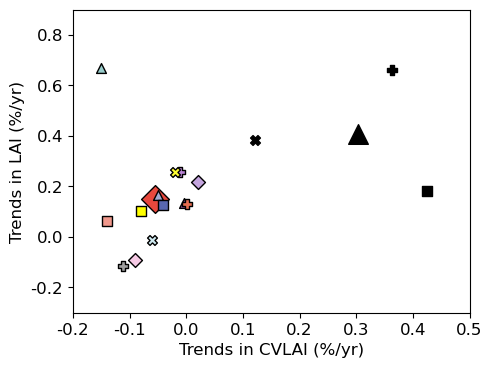

In [3]:
plot_CV_trend_among_models2().run()

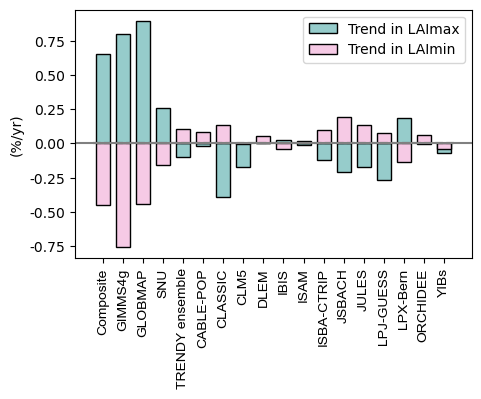

In [4]:
plot_TRENDY_LAImin_LAImax_barplot().run()